In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [113]:
df_ipac = pd.read_csv('hosts_ops.csv')
df_ipac = df_ipac[['pl_orbper', 'st_mass']]
df_ipac = df_ipac[df_ipac['pl_orbper']<1e8]
df_ipac['planet_mass'] = np.random.normal(loc=2, scale=10, size=len(df_ipac))
df_ipac['planet_mass'] = df_ipac['planet_mass']*-1
df_ipac['env_mass'] = df_ipac['planet_mass']*0.04
df_ipac = df_ipac[df_ipac['planet_mass']<-0.1]
df_ipac
df_ipac.to_csv('params2.txt', sep='\t', index=False)
#plt.hist(df_ipac['pl_orbper'])

(array([  31.,   82.,   78.,  127.,  108.,   99.,  142.,  193.,  195.,
         290.,  401.,  761.,  583.,  541.,  664.,  923., 1204., 1948.,
        2072., 2026., 2871., 2457., 2647., 2014.,  957., 1056.,  647.,
         412.,  422.,  226.]),
 array([0.01      , 0.05633333, 0.10266667, 0.149     , 0.19533333,
        0.24166667, 0.288     , 0.33433333, 0.38066667, 0.427     ,
        0.47333333, 0.51966667, 0.566     , 0.61233333, 0.65866667,
        0.705     , 0.75133333, 0.79766667, 0.844     , 0.89033333,
        0.93666667, 0.983     , 1.02933333, 1.07566667, 1.122     ,
        1.16833333, 1.21466667, 1.261     , 1.30733333, 1.35366667,
        1.4       ]),
 <BarContainer object of 30 artists>)

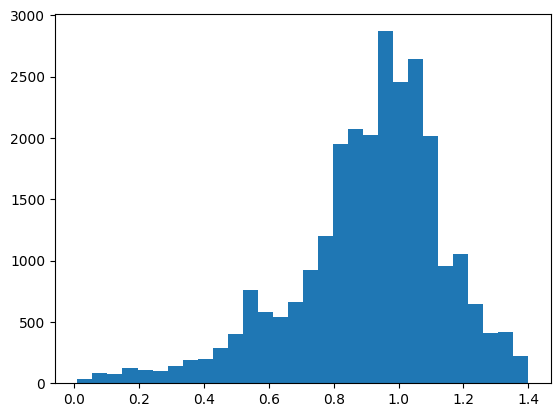

In [114]:
df_hosts = pd.read_csv('STELLARHOSTS_2024.12.03_10.58.46.csv')

df_hosts
plt.hist(df_hosts['st_mass'], bins=30)

(array([1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 2.000e+00, 6.000e+00,
        1.000e+01, 1.500e+01, 1.800e+01, 2.700e+01, 5.100e+01, 7.100e+01,
        1.000e+02, 1.400e+02, 2.070e+02, 2.420e+02, 3.550e+02, 4.450e+02,
        5.850e+02, 7.510e+02, 8.560e+02, 1.033e+03, 1.211e+03, 1.306e+03,
        1.502e+03, 1.611e+03, 1.764e+03, 1.854e+03, 1.831e+03, 1.862e+03]),
 array([-1.79675822, -1.73699964, -1.67724106, -1.61748249, -1.55772391,
        -1.49796533, -1.43820676, -1.37844818, -1.31868961, -1.25893103,
        -1.19917245, -1.13941388, -1.0796553 , -1.01989672, -0.96013815,
        -0.90037957, -0.840621  , -0.78086242, -0.72110384, -0.66134527,
        -0.60158669, -0.54182811, -0.48206954, -0.42231096, -0.36255239,
        -0.30279381, -0.24303523, -0.18327666, -0.12351808, -0.0637595 ,
        -0.00400093]),
 <BarContainer object of 30 artists>)

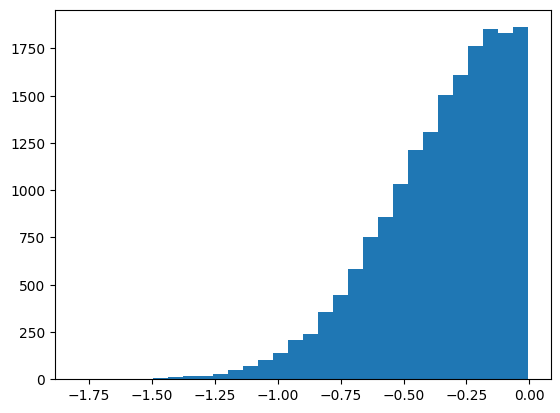

In [115]:
plt.hist(df_ipac['env_mass'], bins=30)

In [116]:
#df_orb_periods = pd.read_csv('PS_2025.02.04_19.13.43.csv')
# pers = df_orb_periods['pl_orbper']
# print(len(pers))
# pers1 = pers.dropna()
# print(len(pers1))
# plt.hist(df_orb_periods['pl_orbper'])

In [117]:
def loguniform(low=0, high=1, size=None):
    return np.exp(np.random.uniform(low, high, size))

In [125]:

# Create a DataFrame
df = pd.DataFrame({})
size=10000
# Add a column with values from a Gaussian distribution
#df['stellar_mass'] = np.random.normal(loc=1, scale=0.5, size=size)
df['stellar_mass']=np.random.choice(df_hosts['st_mass'], size=size)
df['orb_period']=np.random.uniform(10, 60, size=size) #changed from 10-50 to 100
#df['planet_mass'] = np.random.normal(loc=2, scale=10, size=size)
df['planet_mass'] = np.random.rayleigh(scale=3, size=size) # let's call this mass just the core mass
#df['env_mass'] = df['planet_mass']*0.04
scatter = np.random.lognormal(mean=0.0, sigma=0.01, size=len(df))
df['env_frac'] = 0.1 * (df['planet_mass'] / 4.0)**1.7 * scatter
df.loc[df['env_frac'] > 1.0]['env_frac'] = 0.1    # if envelope mass is too high (for low mass planets), set it to default value of 0.1
df["env_mass"] = df['env_frac'] * df['planet_mass']
# loc: Mean of the distribution (default is 0)
# scale: Standard deviation (default is 1)
# size: Number of values to generate (here, same as the length of the DataFrame)
df_total = df
df_min = df[(df['planet_mass']<0.1)|(df['stellar_mass']<0.1)|(df['orb_period']<1e8)]
while len(df_min)>0:
    df=df[(df['planet_mass']>=0.1)&(df['stellar_mass']>=0.1)&(df['stellar_mass']<1.4)]
    df_new = pd.DataFrame({})
    df_new['stellar_mass'] = np.random.normal(loc=1, scale=0.5, size=len(df_min))
    df_new['planet_mass'] = np.random.normal(loc=2.0, scale=1.15, size=len(df_min))
    scatter_new = np.random.lognormal(mean=0.0, sigma=0.01, size=len(df_min))
    df_new['env_frac'] = 0.1 * (df_new["planet_mass"] / 4.0) ** 1.7 * scatter_new
    df_new.loc[df_new['env_frac'] > 1.0]['env_frac'] = 0.1    # if envelope mass is too high (for low mass planets), set it to default value of 0.1
    df_new["env_mass"] = df_new['env_frac'] * df_new['planet_mass']
    df_new['orb_period'] = np.random.uniform(10, 50, size=len(df_min))
    #df_new['orb_period'] = np.random.choice(df_orb_periods['pl_orbper'], size=len(df_min))
    
    df = pd.concat([df, df_new], ignore_index=True, sort=False)
    #print(df)
    df_min = df[(df['planet_mass']<0.1)|(df['stellar_mass']<0.1)]
    
    

df
# Save the array as an .npy file
#df.to_csv('params.txt', sep='\t', index=False)

,stellar_mass,orb_period,planet_mass,env_frac,env_mass
0,1.260000,40.067745,5.857927,0.191994,1.124688
1,0.990000,26.946150,1.217839,0.013048,0.015891
2,1.090000,41.172593,2.174925,0.035389,0.076968
3,0.840000,17.339050,2.540076,0.046579,0.118313
4,0.820000,47.807440,3.349279,0.073671,0.246745
...,...,...,...,...,...
17780,0.475725,18.081608,1.479606,0.018432,0.027272
17781,0.847768,23.559859,0.867008,0.007439,0.006450
17782,1.884660,40.950535,2.052168,0.032121,0.065919
17783,1.928003,26.444331,1.477020,0.018581,0.027445


In [119]:
df.dropna()

,stellar_mass,orb_period,planet_mass,env_frac,env_mass
0,1.010000,18.604190,7.550928,0.291409,2.200406
1,0.580000,10.287629,4.330776,0.113882,0.493196
2,0.930000,34.179560,6.300749,0.214606,1.352178
3,0.400000,43.982310,6.140916,0.208688,1.281534
4,1.120000,23.967421,5.280496,0.160585,0.847969
...,...,...,...,...,...
17777,0.905281,36.463712,1.049323,0.010307,0.010815
17778,1.194300,19.937257,1.164280,0.012300,0.014321
17779,0.697435,42.797965,1.260646,0.014077,0.017747
17780,1.366892,30.428121,2.320050,0.039060,0.090621


In [120]:
add = {'stellar_mass':1.0, 'planet_mass':1.0, 'env_mass':0.1, 'orb_period':30}
df.loc[len(df)] = add
df['planet_mass']=df['planet_mass']*-1
df['env_mass']=df['env_mass']*-1
df['orb_period']=df['orb_period']*-1
df = df.drop(columns=['env_frac']) # to match your format for VPLanet
df

,stellar_mass,orb_period,planet_mass,env_mass
0,1.010000,-18.604190,-7.550928,-2.200406
1,0.580000,-10.287629,-4.330776,-0.493196
2,0.930000,-34.179560,-6.300749,-1.352178
3,0.400000,-43.982310,-6.140916,-1.281534
4,1.120000,-23.967421,-5.280496,-0.847969
...,...,...,...,...
17778,1.194300,-19.937257,-1.164280,-0.014321
17779,0.697435,-42.797965,-1.260646,-0.017747
17780,1.366892,-30.428121,-2.320050,-0.090621
17781,1.231492,-29.063169,-1.270381,-0.017965


In [123]:
df.to_csv('paramsnew.txt', sep='\t', index=False)

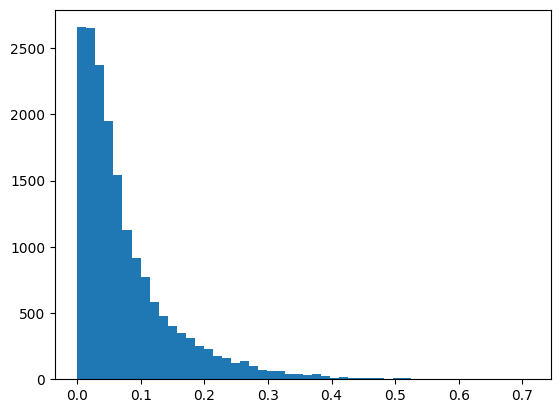

In [124]:
res = plt.hist(df['env_mass'] / df['planet_mass'], bins = 50)